# Exercise 2: CNN Performance vs Signal-to-Noise Ratio

We study the performance of the CNN by varying the amplitude **A** of the patterns
while keeping **DX** fixed, i.e. changing the **signal-to-noise ratio SNR = A / DX**.

The 3-class problem:
- **Class 0**: pure random walk (no pattern)
- **Class 1**: random walk + positive bump of amplitude A over Z bins
- **Class 2**: random walk + negative bump of amplitude A over Z bins

As A increases (higher SNR), patterns become more visible and classification should become easier.

First of all, let's import all the needed libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/CNN

Mounted at /content/drive
/content/drive/MyDrive/CNN


In [6]:
import numpy as np
import pandas as pd
from tensorflow import data
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14


import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from sklearn.model_selection import train_test_split

%run plot.py

In [3]:
def preprocess(x, y, train_size=0.8, random_state=None) -> tuple:
    """
    Splits data into training and validation sets, removes the per-sample mean,
    and normalizes using the average standard deviation of the training set.

    Args:
        x (np.ndarray): Features array of shape (N_samples, L_timesteps).
        y (np.ndarray): Labels array of shape (N_samples,).
        train_size (float, optional): Proportion of the dataset to include in the training split. Defaults to 0.8.
        random_state (int, optional): Seed for reproducible shuffles. Defaults to None.

    Returns:
        tuple: (x_train, y_train, x_val, y_val) formatted as 3D tensors (samples, timesteps, channels)
               ready to be fed into Keras/TensorFlow Conv1D layers.
    """

    x_train, x_val, y_train, y_val = train_test_split(x, y, train_size=train_size, random_state=random_state)

    # Vectorially normalizing train and val sets
    xm_train, xm_val = x_train.mean(axis=1, keepdims=True), x_val.mean(axis=1, keepdims=True)
    std_train, std_val = x_train.std(axis=1), x_val.std(axis=1)
    x_train = (x_train - xm_train) / std_train.mean()
    x_val = (x_val - xm_val) / std_val.mean()


    # Necessary reshape for keras
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)

    return x_train, y_train, x_val, y_val


## CNN model

We use the same CNN architecture as in the lecture notebook (Model 1):
- Conv1D → AveragePooling1D → Conv1D → Flatten → Dense → Dropout → Dense(softmax)

In [4]:
def build_model(L=60, n_class=3) -> tf.keras.Model:
    """
    Build and compile the CNN (same architecture as the lecture notebook).
    Args:
        conf (int): Configuration index.
        L (int): Length of the input sequence.
        n_class (int): Number of classes.
    Returns:
        model (tf.keras.Model): Compiled CNN model.
    """
    input_shape = (L, 1)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)

    model = Sequential([
        Conv1D(filters=5, kernel_size=11, activation='relu',
        kernel_initializer=ini, input_shape=input_shape),
        AveragePooling1D(pool_size=5),
        Conv1D(filters=5, kernel_size=7, activation='relu'),
        Flatten(),
        Dense(12, activation='relu'),
        Dropout(0.5),
        Dense(n_class, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Quick check
m = build_model()
m.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

# Read data

In [5]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# N = Number of samples, L = Number of features
N, L = len(x), len(x[0])

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

## SNR study: sweep over amplitude A

For each value of A we:
1. Generate fresh data (same seed → same noise realisation)
2. Pre-process (mean removal + normalisation)
3. Train the CNN
4. Record validation accuracy

In [7]:
# Fixed parameters
L     = 60
Z     = 12
DX    = 50      # noise level – kept fixed
bias  = 5
N     = 10000

# Amplitude values to scan (SNR = A / DX)
A_values = [0, 50, 100, 150, 200, 250, 300, 400, 500, 700, 1000]

EPOCHS     = 30
BATCH_SIZE = 128

val_accuracies = []

for A in A_values:
    snr = A / DX
    print(f"\n{'='*50}")
    print(f"A = {A:5d}   SNR = A/DX = {snr:.2f}")
    print(f"{'='*50}")

    # 1. Pre-process
    x_train, y_train, x_val, y_val = preprocess(x, y)

    # 2. Build a fresh model
    model = build_model(L=L)

    # 3. Train
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        verbose=0          # set to 1 if you want epoch-by-epoch output
    )

    # 5. Record best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    val_accuracies.append(best_val_acc)
    print(f"Best val accuracy: {best_val_acc:.4f}")


# Saving results to an external CSV
snr_values = [A / DX for A in A_values]
results_df = pd.DataFrame({
    'Amplitude_A': A_values,
    'SNR': snr_values,
    'Best_Val_Accuracy': val_accuracies
})
csv_filename = 'cnn_snr_results.csv'
results_df.to_csv(csv_filename, index=False)


A =     0   SNR = A/DX = 0.00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best val accuracy: 0.9590

A =    50   SNR = A/DX = 1.00
Best val accuracy: 0.9630

A =   100   SNR = A/DX = 2.00
Best val accuracy: 0.9695

A =   150   SNR = A/DX = 3.00
Best val accuracy: 0.9535

A =   200   SNR = A/DX = 4.00
Best val accuracy: 0.9640

A =   250   SNR = A/DX = 5.00
Best val accuracy: 0.9670

A =   300   SNR = A/DX = 6.00
Best val accuracy: 0.9460

A =   400   SNR = A/DX = 8.00
Best val accuracy: 0.9610

A =   500   SNR = A/DX = 10.00
Best val accuracy: 0.9645

A =   700   SNR = A/DX = 14.00
Best val accuracy: 0.9245

A =  1000   SNR = A/DX = 20.00
Best val accuracy: 0.9695


## Results: accuracy vs SNR

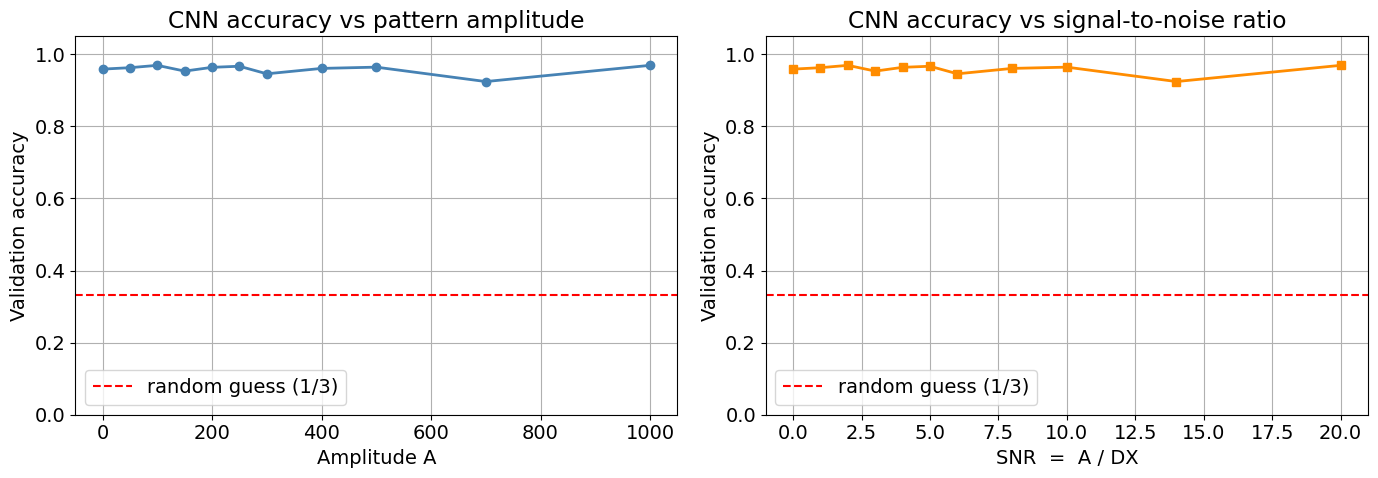

     A       SNR     Val Acc
------------------------------
     0      0.00      0.9590
    50      1.00      0.9630
   100      2.00      0.9695
   150      3.00      0.9535
   200      4.00      0.9640
   250      5.00      0.9670
   300      6.00      0.9460
   400      8.00      0.9610
   500     10.00      0.9645
   700     14.00      0.9245
  1000     20.00      0.9695


In [8]:
snr_values = [A / DX for A in A_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left panel: accuracy vs A ---
ax = axes[0]
ax.plot(A_values, val_accuracies, 'o-', color='steelblue', linewidth=2)
ax.axhline(1/3, color='red', linestyle='--', label='random guess (1/3)')
ax.set_xlabel('Amplitude A')
ax.set_ylabel('Validation accuracy')
ax.set_title('CNN accuracy vs pattern amplitude')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)

# --- right panel: accuracy vs SNR ---
ax = axes[1]
ax.plot(snr_values, val_accuracies, 's-', color='darkorange', linewidth=2)
ax.axhline(1/3, color='red', linestyle='--', label='random guess (1/3)')
ax.set_xlabel('SNR  =  A / DX')
ax.set_ylabel('Validation accuracy')
ax.set_title('CNN accuracy vs signal-to-noise ratio')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('cnn_accuracy_vs_snr.png', dpi=120)
plt.show()

# --- summary table ---
print(f"{'A':>6}  {'SNR':>8}  {'Val Acc':>10}")
print('-' * 30)
for A, snr, acc in zip(A_values, snr_values, val_accuracies):
    print(f"{A:>6}  {snr:>8.2f}  {acc:>10.4f}")